In [159]:
from Charts.ploTools import *
from Charts.resumeTools import *
from glob import glob

In [163]:
PREFIX_EXP = f"OptimizeIterationsResults\\OptunaDDPGExpBase_Total/00000*/*" 
PATH_DATA_LIST_TRAINING_REWARDS_RESUME = glob(PREFIX_EXP + "/training_rewards_resume.pkl")
training_rewards_resume_avg = mean_training_reward_data(PATH_DATA_LIST_TRAINING_REWARDS_RESUME)

In [ ]:
ListToGet = glob("OptimizeIterationsResults/OptunaDDPGExpBase_Total*")

In [147]:
def plotTrainRewardsMeanSTD(FolderName,ExpName, lastN=50, save=False, agentName='DDPG Agent'): 
    # Example :
    # FolderName = OptunaDDPGExpBase_ShuffleDaysTrue
    # ExpName = DDPG Días Aleatorios

    PREFIX_EXP = f"OptimizeIterationsResults\\{FolderName}/00000*/*" 
    PATH_DATA_LIST_TRAINING_REWARDS_RESUME = glob(PREFIX_EXP + "/training_rewards_resume.pkl")
    training_rewards_resume_avg = mean_training_reward_data(PATH_DATA_LIST_TRAINING_REWARDS_RESUME)[agentName]
    # batches of 17 episodes 
    dataToPlotNotCumulative = []
    step_index_adder = 0
    cumulative_reward = 0
    for period_index, rewards in enumerate(training_rewards_resume_avg):
        for step_index, reward in enumerate(rewards):
            cumulative_reward += reward
            dataToPlotNotCumulative.append(reward)
        step_index_adder += len(rewards)

    # i got this dataToPlot (54400) and need to acum each 64 values getting the mean and std and plot it
    dataToPlotNotCumulative = np.array(dataToPlotNotCumulative)
    dataToPlotNotCumulative = dataToPlotNotCumulative.reshape(-1, 64)
    mean = dataToPlotNotCumulative.mean(axis=1)
    dataInBatches = mean.reshape(-1, 17)
    mean = dataInBatches.mean(axis=1)
    std = dataInBatches.std(axis=1)
    # Create a new figure for the mean and std plot
    fig, ax = plt.subplots()
    # Plot the mean and std
    ax.plot(mean, label='Media', color='blue')
    ax.fill_between(range(len(mean)), mean - std, mean + std, color='blue', alpha=0.2, label='Desviación Estándar')
    # Add title and labels
    ax.set_title(f'Media y Desviación Estándar Recompensas - {ExpName}')
    ax.set_xlabel('Lote', fontsize=14)
    ax.set_ylabel('Recompensa', fontsize=14)
    # Set the axis values to font size 12
    ax.tick_params(axis='both', which='major', labelsize=12)
    plt.grid(axis='y')
    # Add a legend
    ax.legend()
    # Show the plot
    if save:
        if agentName == 'DDPG Agent':
            plt.savefig(f"AAAAAMeanSTD_{ExpName.replace(' ','_')}.png", dpi=300, bbox_inches='tight')
        elif agentName == 'SP500 Agent':
            plt.savefig(f"AAAAAMeanSTD_SP500_Agent.png", dpi=300, bbox_inches='tight')
    plt.show()

    return np.array(mean[-lastN:]).mean(), np.array(std[-lastN:]).mean()

In [134]:
ListToGet = glob("OptimizeIterationsResults/OptunaDDPGExpBase*")
ListToGet.pop(-3)
ListToGet.pop(-5)

'OptimizeIterationsResults\\OptunaDDPGExpBase_RewardNetProfit_ShuffleDaysTrue'

In [135]:
ListToGet

['OptimizeIterationsResults\\OptunaDDPGExpBase_CorrelationPunishment05',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_CorrelationPunishment07',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RewardNetProfit',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize10',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize3',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_ShuffleDaysTrue',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_Total']

In [137]:
lastDict = {
'OptunaDDPGExpBase_Total' : 'DDPG valores iniciales',
'OptunaDDPGExpBase_RewardNetProfit' : 'DDPG recompensa de retorno',
'OptunaDDPGExpBase_ShuffleDaysTrue' : 'DDPG días aleatorios',
'OptunaDDPGExpBase_CorrelationPunishment05' : 'DDPG castigo de correlación 0.5',
'OptunaDDPGExpBase_CorrelationPunishment07' : 'DDPG castigo de correlación 0.7',
'OptunaDDPGExpBase_RMemorySize3' : 'DDPG tamaño de ventana 3',
'OptunaDDPGExpBase_RMemorySize10' : 'DDPG tamaño de ventana 10'}

['OptunaDDPGExpBase_Total',
 'OptunaDDPGExpBase_RewardNetProfit',
 'OptunaDDPGExpBase_ShuffleDaysTrue',
 'OptunaDDPGExpBase_CorrelationPunishment05',
 'OptunaDDPGExpBase_CorrelationPunishment07',
 'OptunaDDPGExpBase_RMemorySize3',
 'OptunaDDPGExpBase_RMemorySize10']

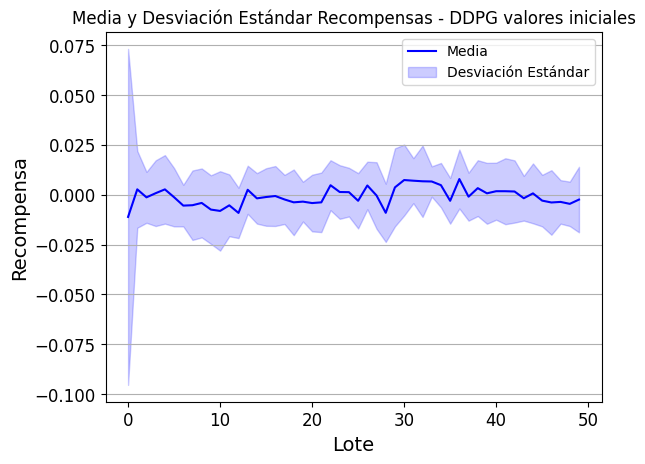

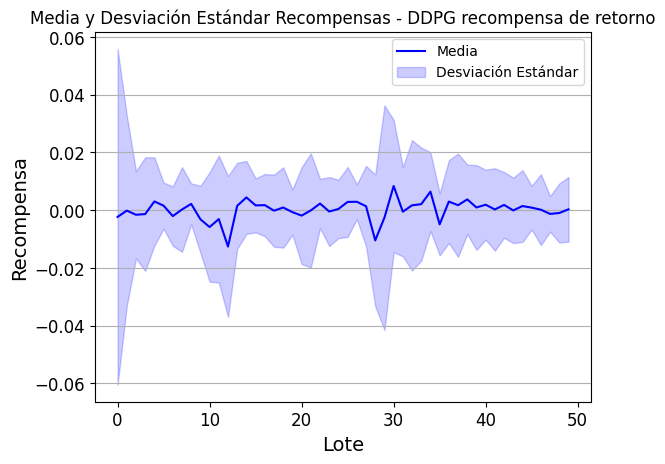

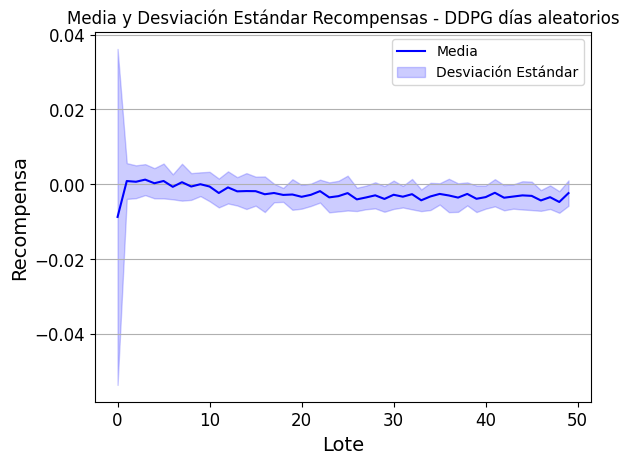

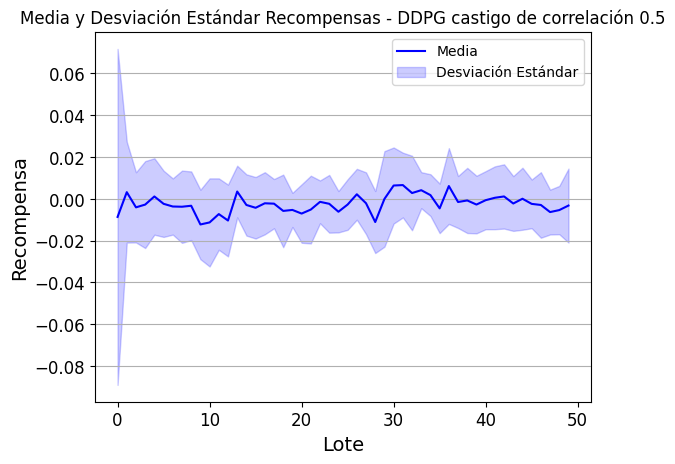

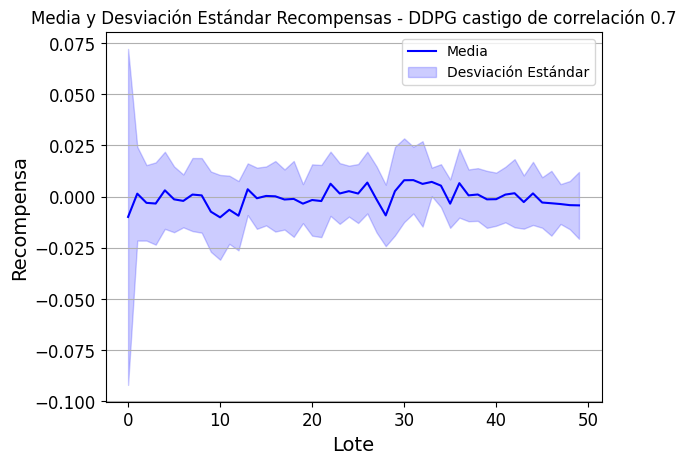

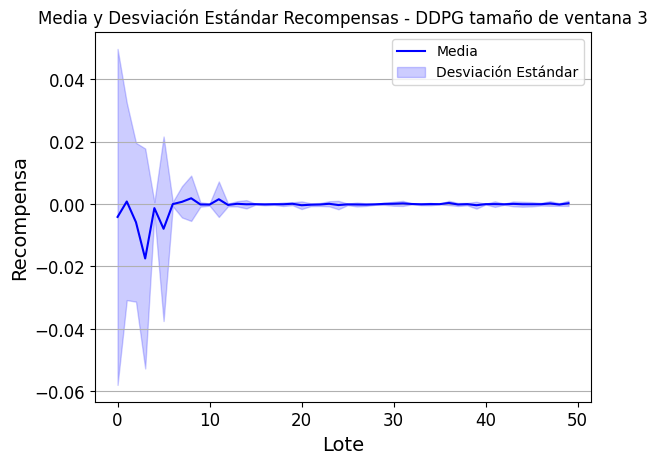

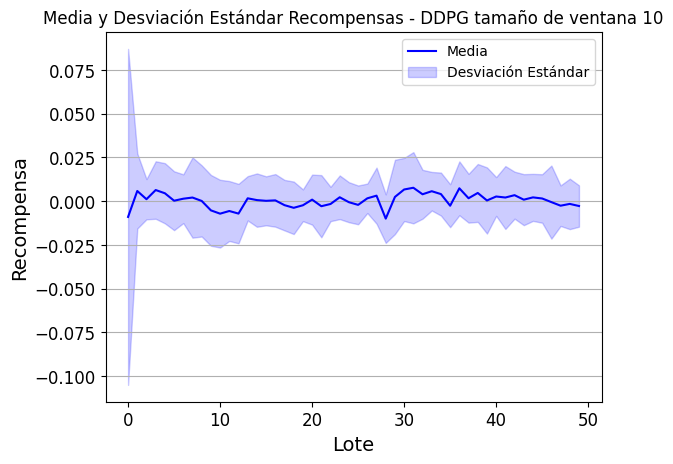

,ExpName,Mean,Std
0,DDPG valores iniciales,0.001297,0.013661
1,DDPG recompensa de retorno,0.001358,0.013641
2,DDPG días aleatorios,-0.003301,0.003415
3,DDPG castigo de correlación 0.5,-0.000162,0.014068
4,DDPG castigo de correlación 0.7,0.000990,0.014030
5,DDPG tamaño de ventana 3,0.000002,0.000541
6,DDPG tamaño de ventana 10,0.002280,0.014789


In [143]:
results = []
for key in list(lastDict.keys()):
    FolderName = key
    ExpName = lastDict[key]
    meanCalculated, stdCalculated = plotTrainRewardsMeanSTD(FolderName,ExpName, 20, True)
    results.append([ExpName, meanCalculated, stdCalculated])

df = pd.DataFrame(results, columns=['ExpName', 'Mean', 'Std'])
df

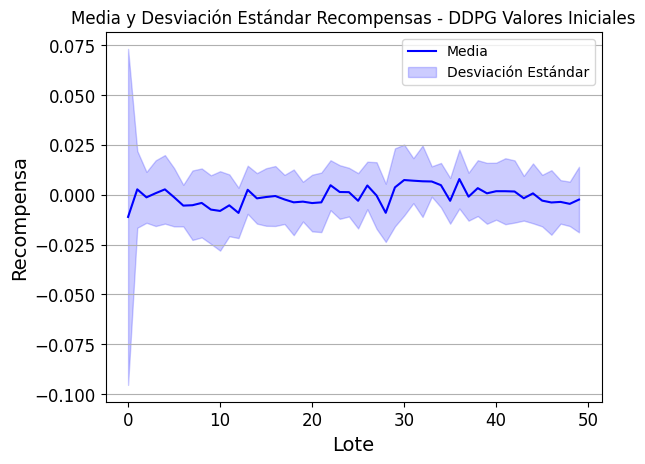

Mean Calculated: 0.0012970820534974337, Std Calculated: 0.013660967350006104


In [122]:
FolderName = "OptunaDDPGExpBase_Total"
ExpName = "DDPG Valores Iniciales"
meanCalculated, stdCalculated = plotTrainRewardsMeanSTD(FolderName,ExpName, 20, True)
print(f'Mean Calculated: {meanCalculated}, Std Calculated: {stdCalculated}')

# NOT CUMULATIVE

In [ ]:
# i got this dataToPlot (54400) and need to acum each 64 values getting the mean and std and plot it
dataToPlotNotCumulative = np.array(dataToPlotNotCumulative)
dataToPlotNotCumulative = dataToPlotNotCumulative.reshape(-1, 64)
mean = dataToPlotNotCumulative.mean(axis=1)
dataInBatches = mean.reshape(-1, 17)
mean = dataInBatches.mean(axis=1)
std = dataInBatches.std(axis=1)
# Create a new figure for the mean and std plot
fig, ax = plt.subplots()
# Plot the mean and std
ax.plot(mean, label='Mean', color='blue')
ax.fill_between(range(len(mean)), mean - std, mean + std, color='blue', alpha=0.2, label='Std Dev')
# Add title and labels
ax.set_title('Media y Desviación Estándar Recompensas - DDPG Agente')
ax.set_xlabel('Batch', fontsize=14)
ax.set_ylabel('Cumulative Reward', fontsize=14)
# Set the axis values to font size 12
ax.tick_params(axis='both', which='major', labelsize=12)
plt.grid(axis='y')
# Add a legend
ax.legend()
# Show the plot
plt.show()

# Ejemplo para acumulado

In [ ]:
# i got this dataToPlot (54400) and need to acum each 64 values getting the mean and std and plot it
dataToPlot = np.array(dataToPlot)
dataToPlot = dataToPlot.reshape(-1, 64)
mean = dataToPlot.mean(axis=1)
dataInBatches = mean.reshape(-1, 17)
mean = dataInBatches.mean(axis=1)
std = dataInBatches.std(axis=1)
# Create a new figure for the mean and std plot
fig, ax = plt.subplots()
# Plot the mean and std
ax.plot(mean, label='Mean', color='blue')
ax.fill_between(range(len(mean)), mean - std, mean + std, color='blue', alpha=0.2, label='Std Dev')
# Add title and labels
ax.set_title('Mean and Std Dev of Cumulative Rewards - DDPG Agent')
ax.set_xlabel('Batch', fontsize=14)
ax.set_ylabel('Cumulative Reward', fontsize=14)
# Set the axis values to font size 12
ax.tick_params(axis='both', which='major', labelsize=12)
plt.grid(axis='y')
# Add a legend
ax.legend()
# Show the plot
plt.show()